In [1]:
import chromadb
client = chromadb.Client()

In [2]:
for c in client.list_collections():
    client.delete_collection(name=c.name)

In [3]:
collection1 = client.create_collection(name="my_collection1")

In [4]:
collection2 = client.create_collection(name="my_collection2")

In [5]:
collection3 = client.create_collection(name="my_collection3")

In [6]:
print(collection3)

Collection(name=my_collection3)


In [7]:
collection2.add(
    documents=["This is a document", "This is another document"],
    metadatas=[{"source": "source1", "language": "en"}, {"source": "source2"}],
    ids=["id1", "id2"]
)

In [8]:
# Get an existing collection

collection1 = client.get_collection(name="my_collection1")
collection2 = client.get_collection(name="my_collection2")
collection2 = client.get_collection(name="my_collection3")

In [9]:
# Get a collection or create if it doesnt exist already

collection3 = client.get_or_create_collection(name="my_collection3")

In [10]:
# Methods can be run on clients

client.list_collections()


[Collection(name=my_collection2),
 Collection(name=my_collection1),
 Collection(name=my_collection3)]

In [11]:
print(client.tenant)
print(client.database)

default_tenant
default_database


In [12]:
# Delete a collection
# client.delete_collection(name='my_collection3')

In [13]:
# Utility methods


# Heartbeat

client.heartbeat()

1774442442228088459

In [14]:
# client.reset()

In [15]:
# Vector DB > Collections > Documents / Items

# Methods can be run on clients


# Count # of items in a collection
collection1.count()

0

In [16]:
# Get items from a collection

collection1.get()

{'ids': [],
 'embeddings': None,
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': []}

In [17]:
# Adding new items into a collection


# One at a time

collection1.add(
    embeddings=None,
    documents=["This is a document 3", "This a document 4"],
    metadatas=[{"source": "source3", "language": "en"}, {"source": "source4"}],
    ids=["id3", "id4"]
)

In [18]:
collection1.peek()

{'ids': ['id3', 'id4'],
 'embeddings': array([[-7.21089467e-02,  7.29400292e-02, -1.33387055e-02,
          1.98304746e-03,  2.88610905e-02, -2.05591694e-03,
         -5.07925823e-02, -3.88301983e-02,  5.15589006e-02,
          4.83009405e-02,  2.30484959e-02,  6.17719442e-02,
         -4.21931185e-02, -3.65653262e-02, -3.89208794e-02,
         -5.89075638e-03, -7.16053993e-02,  3.32885943e-02,
         -3.65207880e-03,  6.47289455e-02,  5.42036779e-02,
          9.00830030e-02,  9.24161896e-02, -7.21398788e-03,
          2.10166294e-02,  5.95515743e-02, -6.73903674e-02,
         -3.91126350e-02,  3.45857926e-02, -5.69936186e-02,
          1.15326978e-02,  3.38021666e-02,  7.95928016e-02,
         -7.23370351e-03,  6.20432682e-02,  7.80299364e-04,
          7.36847743e-02, -2.54506059e-02,  8.94327462e-03,
          9.94131267e-02, -1.07738031e-02, -6.83414042e-02,
         -2.82086972e-02,  1.90096572e-02,  1.45399068e-02,
          4.64889556e-02, -7.80637786e-02, -3.41508947e-02,
  

In [19]:
collection1.get()

{'ids': ['id3', 'id4'],
 'embeddings': None,
 'documents': ['This is a document 3', 'This a document 4'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'language': 'en', 'source': 'source3'}, {'source': 'source4'}]}

In [20]:
collection1.count()

2

In [21]:
# Upsert

collection1.upsert(
    documents=["doc3", "This a document 4"],
    metadatas=[{"source": "source3", "language": "en"}, {"source": "source4"}],
    ids=["id3", "id4"]
)

In [22]:
collection1.get()

{'ids': ['id3', 'id4'],
 'embeddings': None,
 'documents': ['doc3', 'This a document 4'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'language': 'en', 'source': 'source3'}, {'source': 'source4'}]}

In [23]:
collection1.peek()

{'ids': ['id3', 'id4'],
 'embeddings': array([[-7.16050044e-02,  1.18475733e-02,  1.12605533e-02,
         -1.41650401e-02,  3.05321924e-02, -6.06070571e-02,
         -2.86111943e-02,  4.77996469e-02,  7.39508420e-02,
          5.04267812e-02, -1.39318462e-02,  3.14197540e-02,
          1.73165873e-02,  1.14169624e-02,  8.53120349e-03,
         -6.71180338e-03, -1.07235707e-01,  4.48824242e-02,
         -3.58703770e-02,  4.13045101e-02, -5.98775931e-02,
          1.07862443e-01,  4.15820302e-03, -2.84587070e-02,
          3.41652241e-03,  4.01698723e-02, -7.83890262e-02,
         -7.00695515e-02, -2.83143781e-02, -6.23401515e-02,
          1.22925527e-02,  2.37243231e-02,  4.21215594e-02,
         -1.24056237e-02, -2.84376424e-02,  2.34716814e-02,
          2.92859040e-02, -2.39001680e-02, -4.93397862e-02,
          8.05947781e-02, -3.91072929e-02, -3.81805412e-02,
         -3.58463228e-02, -1.73998941e-02,  4.48247232e-02,
         -3.19301039e-02, -8.38236883e-02,  1.01012513e-02,
  

In [24]:
neo_collection = client.create_collection(name="neo")

In [25]:
print(neo_collection)

Collection(name=neo)


In [26]:
# Rename the collection name and inspecting it again

neo_collection.modify(name="mr_anderson")
print(neo_collection)

Collection(name=mr_anderson)


In [27]:
# Counting items

item_count = neo_collection.count()
print(f"of items in collection: {item_count}")

of items in collection: 0


In [28]:
# Distance


In [29]:
#print(trinity_collection)

In [30]:
# Get or Create a new collection, and change the distance function

trinity_collection = client.get_or_create_collection(
    name="trinity", metadata={"hnsw:space":"cosine"}
)
print(trinity_collection)

Collection(name=trinity)


In [31]:
# Deleting a Collection

try:
  client.delete_collection(name="mr_anderson")
  print("Mr. Anderson collection deleted.")
except ValueError as e:
  print(f"Error: {e}")

neo_collection = client.create_collection(name="neo")

Mr. Anderson collection deleted.


In [32]:
# Adding data
# Adding raw documents

neo_collection.add(
    documents=[
        "There us bi spoon.",
        "I know kung fu."
    ],
    ids=["quote1", "quote2"]
)

In [33]:
# Upsert

neo_collection.upsert(
    documents=["There is no spoon.", "I know kung fu."],
    ids=["quote1", "quote2"]
)

In [34]:
item_count = neo_collection.count()
print(f"Count of items in collection: {item_count}")


Count of items in collection: 2


In [35]:
neo_collection.get()

{'ids': ['quote1', 'quote2'],
 'embeddings': None,
 'documents': ['There is no spoon.', 'I know kung fu.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None]}

In [36]:
neo_collection.peek(limit=1)

{'ids': ['quote1'],
 'embeddings': array([[ 4.50641289e-03, -7.76351690e-02, -3.88775878e-02,
         -1.23527283e-02, -8.39507505e-02,  4.84782569e-02,
          2.70228963e-02, -8.26054215e-02,  7.58571178e-02,
          1.64956041e-02,  3.45768631e-02, -6.97631761e-02,
         -1.25152385e-02, -5.83279543e-02, -7.36757442e-02,
         -1.22720554e-01, -3.31801139e-02, -1.08264811e-01,
         -1.07758781e-02,  2.41387216e-03,  3.13210338e-02,
          3.63168801e-04,  5.74709103e-02, -1.93405673e-02,
          6.21309243e-02,  5.51330745e-02,  1.94749702e-02,
         -6.18175380e-02, -2.54653525e-02,  6.34439811e-02,
         -1.93185359e-02, -5.40940138e-03, -8.22466239e-02,
         -4.52789366e-02,  3.76525968e-02,  7.05910474e-03,
          5.04518896e-02,  4.01081741e-02,  5.01829386e-02,
          1.59695391e-02, -6.82597756e-02, -7.21675307e-02,
         -5.08137047e-02,  9.78314783e-03,  4.41795252e-02,
          3.99049446e-02, -1.12011312e-02, -6.45495206e-02,
      

In [37]:
# Adding document Morpheus associated embeddings

morpheus_collection = client.get_or_create_collection(name="morpheus")

morpheus_collection.add (
    documents =[
    "Welcome to the real world.",
    "What if I told you everything you knew was a lie. "],
    embeddings = [[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]],
    ids = ["quote1", "quote2"]
)

In [38]:
morpheus_collection.count()

2

In [39]:
morpheus_collection.get()

{'ids': ['quote1', 'quote2'],
 'embeddings': None,
 'documents': ['Welcome to the real world.',
  'What if I told you everything you knew was a lie. '],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None]}

In [40]:
# Adding embeddings and metada

In [41]:
locations_colletcion = client.create_collection(name="locations")

In [42]:
client.delete_collection(name="locations")

In [43]:
# locations_collection = client.create_collection("locations")

In [44]:
# # Adding embbedings and metada
# locations_colletcion.add(
#     embeddings=[[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]],
#     metadatas=[{"location": "Machine City", "description": "City inhabited by machines"},
#                 {"location": "Zion","description": "Last huma city"},
#                 ],
#     ids=["location1", "location2"]
# )

In [45]:
# locations_colletcion.count()

In [46]:
# locations_colletcion.get()

In [47]:
# Query texts

try:
    client.delete_collection(name="morpheus")
    print(f"Collection deleted.")
except ValueError as e:
    print(f"Error: {e}")


morpheus_collection = client.create_collection(
    name="morpheus",
    metadata={"hnsw:space": "cosine"}
)

Collection deleted.


In [48]:
morpheus_collection.add(
    documents=["This is your last chance. After this, there is no turning back.",
                "You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.",
                "You take the red pill, you stay in Wonderland and start to live."

    ],
    ids=["quote1", "quote2", "quote3"]

)

In [49]:
morpheus_collection.get()

{'ids': ['quote1', 'quote2', 'quote3'],
 'embeddings': None,
 'documents': ['This is your last chance. After this, there is no turning back.',
  'You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.',
  'You take the red pill, you stay in Wonderland and start to live.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None]}

In [50]:
# Querying by a set of query_texts

results = morpheus_collection.query(
    query_texts=["Take the red pill?"],
    n_results=2
)

print(results)

{'ids': [['quote3', 'quote2']], 'embeddings': None, 'documents': [['You take the red pill, you stay in Wonderland and start to live.', 'You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[None, None]], 'distances': [[0.3925292491912842, 0.5061869621276855]]}


In [51]:
# Query by ID
# Add the raw documents
trinity_collection.add(
    documents=["Dodge this.",
                "I think they're trying to tell us something.",
                "Neo, no one has ever done this before."
            ],
    ids=["quote1", "quote2", "quote3"]

)


In [52]:
items = trinity_collection.get(ids=["quote2","quote3"])
print(items)

{'ids': ['quote2', 'quote3'], 'embeddings': None, 'documents': ["I think they're trying to tell us something.", 'Neo, no one has ever done this before.'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [None, None]}


In [53]:
# Choosing which data is returned from a collection

# Query the collection by text and choose which data is returned

results = morpheus_collection.query(
    query_texts=["Take the red pill?"],
    n_results=2,
    include=["embeddings", "distances"]
)

print(results)

{'ids': [['quote3', 'quote2']], 'embeddings': [array([[ 9.18314233e-02, -5.30762039e-02, -5.08151092e-02,
         7.59122372e-02,  3.30477431e-02,  8.37379545e-02,
         1.00986287e-01, -2.25555319e-02,  2.10875776e-02,
        -4.89779748e-02, -4.28554863e-02,  1.00734672e-02,
        -3.69011401e-03,  4.48942278e-03, -1.46785351e-02,
         5.49721019e-03, -3.63165070e-03, -2.30305884e-02,
        -5.44368960e-02,  4.16080691e-02, -4.04384434e-02,
         1.41983544e-02,  4.95129973e-02,  6.75570816e-02,
        -6.88114166e-02,  4.68169861e-02, -5.15902601e-03,
        -1.82429142e-03, -8.66317526e-02, -1.54587869e-02,
         1.06904976e-01,  1.69814341e-02,  2.86219399e-02,
        -1.86769590e-02, -3.16647850e-02,  7.91082904e-02,
         4.05352190e-02, -2.94110384e-02,  2.60772780e-02,
         3.30385715e-02, -1.40196523e-02, -3.30065899e-02,
        -1.12453485e-02,  7.22390711e-02,  3.10493428e-02,
        -2.03841506e-03, -7.77192861e-02,  6.52305558e-02,
         

In [54]:
# Using where filter

# Create the collection

matrix_collection = client.create_collection(name="matrix")

In [55]:
# Add the raw documents

matrix_collection.add(
    documents=[
        "The Matrix is everywhere, it is all around us.",
        "Unfortunately, no one can be told what the Matrix is",
        "You can see it when you look out your window or when you turn on your television.",
        "You are a plague, Mr. Anderson. You and your kind are a cancer of this planet.",
        "You hear that Mr. Anderson?... That is the sound of inevitability...",

    ],
    metadatas=[{"category": "quote","speaker": "Morpheus"},
                {"category": "quote","speaker": "Morpheus"},
                {"category": "quote","speaker": "Morpheus"},
                {"category": "quote","speaker": "Agent Smith"},
                {"category": "quote","speaker": "Agent Smith"},
                ],
    ids=["quote1", "quote2", "quote3", "quote4", "quote5"]
)

In [56]:
# Querying with where filters

results = matrix_collection.query(
    query_texts=["What is the Matrix?"],
    n_results=2,
    where={"speaker": "Morpheus"},
)

print(results)

{'ids': [['quote2', 'quote1']], 'embeddings': None, 'documents': [['Unfortunately, no one can be told what the Matrix is', 'The Matrix is everywhere, it is all around us.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'speaker': 'Morpheus', 'category': 'quote'}, {'category': 'quote', 'speaker': 'Morpheus'}]], 'distances': [[0.4784316420555115, 0.8001493811607361]]}


In [57]:
# Update items in the collection

matrix_collection.update(
    ids=["quote2"],
    metadatas=[{"category": "quote", "speaker": "Morpheus"}],
    documents=["The Matris is a system, Neo. That system is our enemy"],
)

In [58]:
items = matrix_collection.get(ids=["quote2"])
print(items)

{'ids': ['quote2'], 'embeddings': None, 'documents': ['The Matris is a system, Neo. That system is our enemy'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'speaker': 'Morpheus', 'category': 'quote'}]}


In [59]:
# Upsert Operations

matrix_collection.get()

{'ids': ['quote1', 'quote2', 'quote3', 'quote4', 'quote5'],
 'embeddings': None,
 'documents': ['The Matrix is everywhere, it is all around us.',
  'The Matris is a system, Neo. That system is our enemy',
  'You can see it when you look out your window or when you turn on your television.',
  'You are a plague, Mr. Anderson. You and your kind are a cancer of this planet.',
  'You hear that Mr. Anderson?... That is the sound of inevitability...'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'speaker': 'Morpheus', 'category': 'quote'},
  {'category': 'quote', 'speaker': 'Morpheus'},
  {'category': 'quote', 'speaker': 'Morpheus'},
  {'speaker': 'Agent Smith', 'category': 'quote'},
  {'speaker': 'Agent Smith', 'category': 'quote'}]}

In [60]:
# Upsert operations

matrix_collection.upsert(
    ids=["quote2", "quote4"],
    metadatas=[{"category": "quote", "speaker": "Morpheus"},
                {"category": "quote", "speaker": "Agent Smith"}
    ],
    documents=["You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.",
                "I'm going to enjoy watching you die, Mr. Anderson"
                ],
)

In [61]:
matrix_collection.get()

{'ids': ['quote1', 'quote2', 'quote3', 'quote4', 'quote5'],
 'embeddings': None,
 'documents': ['The Matrix is everywhere, it is all around us.',
  'You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.',
  'You can see it when you look out your window or when you turn on your television.',
  "I'm going to enjoy watching you die, Mr. Anderson",
  'You hear that Mr. Anderson?... That is the sound of inevitability...'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'category': 'quote', 'speaker': 'Morpheus'},
  {'speaker': 'Morpheus', 'category': 'quote'},
  {'speaker': 'Morpheus', 'category': 'quote'},
  {'category': 'quote', 'speaker': 'Agent Smith'},
  {'category': 'quote', 'speaker': 'Agent Smith'}]}

In [62]:
# Delete by ID

trinity_collection.get()


{'ids': ['quote1', 'quote2', 'quote3'],
 'embeddings': None,
 'documents': ['Dodge this.',
  "I think they're trying to tell us something.",
  'Neo, no one has ever done this before.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None]}

In [63]:
trinity_collection.delete(ids=["quote3"])

{'deleted': 1}

In [64]:
trinity_collection.get()

{'ids': ['quote1', 'quote2'],
 'embeddings': None,
 'documents': ['Dodge this.', "I think they're trying to tell us something."],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None]}

In [65]:
# Add more items

matrix_collection.add(
    documents=[
        "The Matrix is everywhere, it is all around us.",
        "You can see it when you look out your window or when you turn on your television.",
        "You can fee it when you go to work, when you go to church, when you pay your taxes.",
        "It seems that you've been living two lives.",
        "I believe that, as a species, human beings define their reality through misery and suffering",
        "Human beings are a disease, a cancer of this planet.",

    ],
    metadatas=[{"category": "quote","speaker": "Morpheus"},
                {"category": "quote","speaker": "Morpheus"},
                {"category": "quote","speaker": "Morpheus"},
                {"category": "quote","speaker": "Agent Smith"},
                {"category": "quote","speaker": "Agent Smith"},
                {"category": "quote","speaker": "Agent Smith"}
                ],
    ids=["quote1", "quote2", "quote3", "quote4", "quote5", "quote6"]
)

In [66]:
matrix_collection.get()

{'ids': ['quote1', 'quote2', 'quote3', 'quote4', 'quote5', 'quote6'],
 'embeddings': None,
 'documents': ['The Matrix is everywhere, it is all around us.',
  'You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.',
  'You can see it when you look out your window or when you turn on your television.',
  "I'm going to enjoy watching you die, Mr. Anderson",
  'You hear that Mr. Anderson?... That is the sound of inevitability...',
  'Human beings are a disease, a cancer of this planet.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'category': 'quote', 'speaker': 'Morpheus'},
  {'speaker': 'Morpheus', 'category': 'quote'},
  {'category': 'quote', 'speaker': 'Morpheus'},
  {'speaker': 'Agent Smith', 'category': 'quote'},
  {'speaker': 'Agent Smith', 'category': 'quote'},
  {'speaker': 'Agent Smith', 'category': 'quote'}]}

In [67]:
# Delete with 'where' filter

matrix_collection.delete(where={"speaker": "Agent Smith"})

{'deleted': 3}

In [68]:
item_count = matrix_collection.count()
print(f"Count of items in collection: {item_count}")

Count of items in collection: 3


In [69]:
matrix_collection.get()

{'ids': ['quote1', 'quote2', 'quote3'],
 'embeddings': None,
 'documents': ['The Matrix is everywhere, it is all around us.',
  'You take the blue pill, the story ends, you wake up in your bed and believe whatever you want to believe.',
  'You can see it when you look out your window or when you turn on your television.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'speaker': 'Morpheus', 'category': 'quote'},
  {'speaker': 'Morpheus', 'category': 'quote'},
  {'category': 'quote', 'speaker': 'Morpheus'}]}

In [70]:
import os

In [71]:
# import langchain
# print(langchain.__version__)
# print(dir(langchain))

In [72]:
# import sys
# import langchain

# print(sys.executable)
# print(langchain.__file__)

In [73]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_text_splitters import CharacterTextSplitter
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.chains.retrieval import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate

/home/vboxuser/Documents/nlp-clean/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [74]:
# !unzip -q techcrunch_articles.zip -d articles

In [75]:
from langchain_community.document_loaders import TextLoader
import chardet

def detect_encoding(file_path):
    with open(file_path, "rb") as f:
        raw = f.read()
        result = chardet.detect(raw)
        return result["encoding"]

encoding = detect_encoding("/home/vboxuser/Documents/nlp-clean/TextFiles/huckfinn.txt")

loader = TextLoader(
    "/home/vboxuser/Documents/nlp-clean/TextFiles/huckfinn.txt",
    encoding=encoding
)

documents = loader.load()

In [76]:
print(documents)

[Document(metadata={'source': '/home/vboxuser/Documents/nlp-clean/TextFiles/huckfinn.txt'}, page_content="ADVENTURES OF HUCKLEBERRY FINN\n\nBy Mark Twain\n\n\nEXPLANATORY\n\nIN this book a number of dialects are used, to wit: \xa0the Missouri negro\ndialect; the extremest form of the backwoods Southwestern dialect; the\nordinary \x93Pike County\x94 dialect; and four modified varieties of this\nlast. The shadings have not been done in a haphazard fashion, or by\nguesswork; but painstakingly, and with the trustworthy guidance and\nsupport of personal familiarity with these several forms of speech.\n\nI make this explanation for the reason that without it many readers\nwould suppose that all these characters were trying to talk alike and\nnot succeeding.\n\nTHE AUTHOR.\n\n\n\nHUCKLEBERRY FINN\n\nScene: \xa0The Mississippi Valley Time: \xa0Forty to fifty years ago\n\n\n\n\nCHAPTER I.\n\nYOU don't know about me without you have read a book by the name of The\nAdventures of Tom Sawyer; but t

In [77]:
# Split the text into chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = text_splitter.split_documents(documents)

In [78]:
texts

[Document(metadata={'source': '/home/vboxuser/Documents/nlp-clean/TextFiles/huckfinn.txt'}, page_content='ADVENTURES OF HUCKLEBERRY FINN\n\nBy Mark Twain\n\n\nEXPLANATORY\n\nIN this book a number of dialects are used, to wit: \xa0the Missouri negro\ndialect; the extremest form of the backwoods Southwestern dialect; the\nordinary \x93Pike County\x94 dialect; and four modified varieties of this\nlast. The shadings have not been done in a haphazard fashion, or by\nguesswork; but painstakingly, and with the trustworthy guidance and\nsupport of personal familiarity with these several forms of speech.\n\nI make this explanation for the reason that without it many readers\nwould suppose that all these characters were trying to talk alike and\nnot succeeding.\n\nTHE AUTHOR.\n\n\n\nHUCKLEBERRY FINN\n\nScene: \xa0The Mississippi Valley Time: \xa0Forty to fifty years ago\n\n\n\n\nCHAPTER I.'),
 Document(metadata={'source': '/home/vboxuser/Documents/nlp-clean/TextFiles/huckfinn.txt'}, page_content

In [79]:
len(texts)

807

In [80]:
# from dotenv import load_dotenv
# import os

# load_dotenv(override=True)

# print(os.getenv("OPENAI_API_KEY"))

In [81]:
# Create a ChromaDB

In [82]:
# persist_directory = "db"

# embedding = OpenAIEmbeddings()

In [83]:
# # Persist in OpenAI, Gemini, Anthropic and etc

# vectordb = Chroma.from_documents(
#   documents= texts,
#   embedding= embedding,
#   persist_directory= persist_directory
# )

In [84]:
import shutil
shutil.rmtree("db", ignore_errors=True)

In [85]:
# vectordb = Chroma.from_documents(
#     documents=texts,
#     embedding=embedding,
#     persist_directory="db"
# )

# vectordb.persist()

In [86]:
from langchain_community.document_loaders import TextLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.text_splitter import CharacterTextSplitter
import chardet

# Detectar encoding
def detect_encoding(file_path):
    with open(file_path, "rb") as f:
        raw = f.read()
        result = chardet.detect(raw)
        return result["encoding"]

file_path = "/home/vboxuser/Documents/nlp-clean/TextFiles/huckfinn.txt"

encoding = detect_encoding(file_path)

# Load do documento
loader = TextLoader(file_path, encoding=encoding)
documents = loader.load()

# Split (IMPORTANTE para embeddings)
text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=50)
texts = text_splitter.split_documents(documents)

# Embedding LOCAL (sem API)
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Persistência
persist_directory = "db"

vectordb = Chroma.from_documents(
    documents=texts,
    embedding=embedding,
    persist_directory=persist_directory
)

# Salvar no disco
vectordb.persist()

print("Banco vetorial persistido com sucesso!")

Created a chunk of size 414, which is longer than the specified 100
Created a chunk of size 153, which is longer than the specified 100
Created a chunk of size 559, which is longer than the specified 100
Created a chunk of size 898, which is longer than the specified 100
Created a chunk of size 757, which is longer than the specified 100
Created a chunk of size 295, which is longer than the specified 100
Created a chunk of size 548, which is longer than the specified 100
Created a chunk of size 1103, which is longer than the specified 100
Created a chunk of size 410, which is longer than the specified 100
Created a chunk of size 1758, which is longer than the specified 100
Created a chunk of size 735, which is longer than the specified 100
Created a chunk of size 479, which is longer than the specified 100
Created a chunk of size 699, which is longer than the specified 100
Created a chunk of size 165, which is longer than the specified 100
Created a chunk of size 724, which is longer t

Created a chunk of size 191, which is longer than the specified 100
Created a chunk of size 111, which is longer than the specified 100
Created a chunk of size 174, which is longer than the specified 100
Created a chunk of size 216, which is longer than the specified 100
Created a chunk of size 119, which is longer than the specified 100
Created a chunk of size 225, which is longer than the specified 100
Created a chunk of size 128, which is longer than the specified 100
Created a chunk of size 223, which is longer than the specified 100
Created a chunk of size 351, which is longer than the specified 100
Created a chunk of size 288, which is longer than the specified 100
Created a chunk of size 254, which is longer than the specified 100
Created a chunk of size 170, which is longer than the specified 100
Created a chunk of size 268, which is longer than the specified 100
Created a chunk of size 357, which is longer than the specified 100
Created a chunk of size 141, which is longer tha

Banco vetorial persistido com sucesso!


/tmp/ipykernel_27336/806792994.py:41: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


In [87]:
vectorbd = Chroma(
  persist_directory= persist_directory,
  embedding_function= embedding
)

/tmp/ipykernel_27336/1052068166.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the langchain-chroma package and should be used instead. To use it run `pip install -U langchain-chroma` and import as `from langchain_chroma import Chroma`.
  vectorbd = Chroma(


In [88]:
# perist the db to the disk

vectorbd.persist()
vectorbd = None

In [89]:
# Create a retrevier

In [90]:
retriever = vectordb.as_retriever()

In [91]:
retriever = vectordb.as_retriever(search_kwargs={"k":2})

In [92]:
retriever.search_type

'similarity'

In [93]:
retriever.search_kwargs

{'k': 2}

In [94]:
# from langchain_openai import ChatOpenAI

# turbo_llm = ChatOpenAI(
#     temperature=0,
#     model="gpt-3.5-turbo"
# )

In [95]:
# from langchain.chains import RetrievalQA

# qa_chain = RetrievalQA.from_chain_type(
#   llm = turbo_llm,
#   chain_type="stuff",
#   retriever = retriever,
#   return_source_documents=True
# )

In [96]:
# query = "What is the news about Pando?"
# llm_response = qa_chain(query)
# llm_response

In [97]:
# helper function to display output

In [98]:
# def process_llm_response(llm_response):
#   print(llm_response["result"])
#   print('\n\nSources:')
#   for source in llm_response["source_documents"]:
#     print(source.metada['source'])

In [99]:
# query = "What is the news about Pando?"
# llm_response = qa_chain(query)

In [100]:
from chromadb.utils import embedding_functions

In [101]:
# create a colletcion with default embedding

collection = client.create_collection(
  name="stocks",
  embedding_function= embedding_functions.DefaultEmbeddingFunction(),
  get_or_create= True
)

In [102]:
print(collection)

Collection(name=stocks)


In [103]:
import pandas as pd
import wikipedia
import requests
import time

In [104]:
def get_wikipedia_summary(name):
  try:
    summary = wikipedia.summary(name + 'company')
  except:
    summary = None 
  finally:
    return summary    

In [105]:
# This will take 2-5 min or more.

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

df = pd.read_html(response.text, attrs={"id": "constituents"})[0]

print(df.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


/tmp/ipykernel_27336/404914107.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(response.text, attrs={"id": "constituents"})[0]


In [106]:
df.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [107]:
# from langchain.schema import Document

# documents = []

# for _, row in df.iterrows():
#     content = f"""
#     Company: {row['Security']}
#     Symbol: {row['Symbol']}
#     Sector: {row['GICS Sector']}
#     Sub-Industry: {row['GICS Sub-Industry']}
#     Location: {row['Headquarters Location']}
#     Founded: {row['Founded']}
#     """

#     doc = Document(
#         page_content=content,
#         metadata={
#             "symbol": row["Symbol"],
#             "sector": row["GICS Sector"]
#         }
#     )

#     documents.append(doc)

# print(f"Total documentos: {len(documents)}")

In [108]:
# import time
# import wikipedia

# def get_summary(name):
#     try:
#         time.sleep(1)  # evita bloqueio
#         return wikipedia.summary(name, sentences=2)
#     except:
#         return None

# df['company_summary'] = df['Security'].apply(get_summary)

In [109]:
# def get_summary(name):
#     try:
#         time.sleep(1)  # evita bloqueio
#         return wikipedia.summary(name, sentences=2)
#     except:
#         return None

# df['company_summary'] = df['Security'].apply(get_summary)

In [110]:
df['company_summary'] = df['Security']

In [111]:
import re

def extract_year(value):
    match = re.search(r"\d{4}", str(value))
    return int(match.group()) if match else None

cleaned_df = (
    df[df['company_summary'].notnull()]
    .assign(
        date_founded=lambda x: x['Founded'].apply(extract_year),
        date_added=lambda x: x['Date added']
    )
    [['Security', 'GICS Sector', 'GICS Sub-Industry', 'date_founded', 'date_added', 'company_summary']]
    .dropna()
    .reset_index(drop=True)
)

# Preparação para vector DB
documents = cleaned_df['company_summary'].tolist()
ids = cleaned_df.index.astype(str).tolist()
metadata = cleaned_df.drop('company_summary', axis=1).to_dict(orient='records')

In [112]:
print(documents)

['3M', 'A. O. Smith', 'Abbott Laboratories', 'AbbVie', 'Accenture', 'Adobe Inc.', 'Advanced Micro Devices', 'AES Corporation', 'Aflac', 'Agilent Technologies', 'Air Products', 'Airbnb', 'Akamai Technologies', 'Albemarle Corporation', 'Alexandria Real Estate Equities', 'Align Technology', 'Allegion', 'Alliant Energy', 'Allstate', 'Alphabet Inc. (Class A)', 'Alphabet Inc. (Class C)', 'Altria', 'Amazon', 'Amcor', 'Ameren', 'American Electric Power', 'American Express', 'American International Group', 'American Tower', 'American Water Works', 'Ameriprise Financial', 'Ametek', 'Amgen', 'Amphenol', 'Analog Devices', 'Aon plc', 'APA Corporation', 'Apollo Global Management', 'Apple Inc.', 'Applied Materials', 'AppLovin', 'Aptiv', 'Arch Capital Group', 'Archer Daniels Midland', 'Ares Management', 'Arista Networks', 'Arthur J. Gallagher & Co.', 'Assurant', 'AT&T', 'Atmos Energy', 'Autodesk', 'Automatic Data Processing', 'AutoZone', 'AvalonBay Communities', 'Avery Dennison', 'Axon Enterprise', 'B

In [113]:
ids

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138'

In [114]:
metadata

[{'Security': '3M',
  'GICS Sector': 'Industrials',
  'GICS Sub-Industry': 'Industrial Conglomerates',
  'date_founded': 1902,
  'date_added': '1957-03-04'},
 {'Security': 'A. O. Smith',
  'GICS Sector': 'Industrials',
  'GICS Sub-Industry': 'Building Products',
  'date_founded': 1916,
  'date_added': '2017-07-26'},
 {'Security': 'Abbott Laboratories',
  'GICS Sector': 'Health Care',
  'GICS Sub-Industry': 'Health Care Equipment',
  'date_founded': 1888,
  'date_added': '1957-03-04'},
 {'Security': 'AbbVie',
  'GICS Sector': 'Health Care',
  'GICS Sub-Industry': 'Biotechnology',
  'date_founded': 2013,
  'date_added': '2012-12-31'},
 {'Security': 'Accenture',
  'GICS Sector': 'Information Technology',
  'GICS Sub-Industry': 'IT Consulting & Other Services',
  'date_founded': 1989,
  'date_added': '2011-07-06'},
 {'Security': 'Adobe Inc.',
  'GICS Sector': 'Information Technology',
  'GICS Sub-Industry': 'Application Software',
  'date_founded': 1982,
  'date_added': '1997-05-05'},
 {'S

In [115]:
collection.add(
  ids = ids,
  documents = documents,
  metadatas=metadata
)

In [116]:
collection.count()

503

In [117]:
# Query data

In [118]:
results = collection.query(
  query_texts="IT Consulting & Other Services",
  n_results=4
)

results

{'ids': [['316', '489', '404', '379']],
 'embeddings': None,
 'documents': [['Microsoft',
   'West Pharmaceutical Services',
   'Salesforce',
   'Public Service Enterprise Group']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'date_added': '1994-06-01',
    'GICS Sub-Industry': 'Systems Software',
    'date_founded': 1975,
    'Security': 'Microsoft',
    'GICS Sector': 'Information Technology'},
   {'date_founded': 1923,
    'GICS Sub-Industry': 'Health Care Supplies',
    'Security': 'West Pharmaceutical Services',
    'date_added': '2020-05-22',
    'GICS Sector': 'Health Care'},
   {'date_founded': 1999,
    'GICS Sub-Industry': 'Application Software',
    'GICS Sector': 'Information Technology',
    'date_added': '2008-09-15',
    'Security': 'Salesforce'},
   {'GICS Sector': 'Utilities',
    'Security': 'Public Service Enterprise Group',
    'GICS Sub-Industry': 'Electric Utilities',
    'date_added': '1957-03-04',
    'dat

In [119]:
# Query using condition where

results = collection.query(
  query_texts="IT Consulting & Other Services",
  n_results=4,
  where = {'GICS Sector': 'Information Technology'}
)

results

{'ids': [['316', '404', '353', '246']],
 'embeddings': None,
 'documents': [['Microsoft', 'Salesforce', 'Oracle Corporation', 'IBM']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'GICS Sector': 'Information Technology',
    'date_founded': 1975,
    'Security': 'Microsoft',
    'date_added': '1994-06-01',
    'GICS Sub-Industry': 'Systems Software'},
   {'date_founded': 1999,
    'date_added': '2008-09-15',
    'Security': 'Salesforce',
    'GICS Sub-Industry': 'Application Software',
    'GICS Sector': 'Information Technology'},
   {'GICS Sub-Industry': 'Application Software',
    'date_founded': 1977,
    'date_added': '1989-08-31',
    'Security': 'Oracle Corporation',
    'GICS Sector': 'Information Technology'},
   {'date_founded': 1911,
    'GICS Sub-Industry': 'IT Consulting & Other Services',
    'GICS Sector': 'Information Technology',
    'date_added': '1957-03-04',
    'Security': 'IBM'}]],
 'distances': [[1.1437494754

In [120]:
# more filters

#$eq: equal to.
#$ne: not equal to.
#$gt: greater than.
#$gte: greater than or equal to.
#$lt: less than.
#$lte: less than or equal to.

In [121]:
# apply filters

where_clause = {
  "$and" : [
    {"GICS Sector": {"$eq":"Information Technology"}},
    {"date_founded": {"$gte":1977}}
  ]
}

results = collection.query(
  query_texts="Information Technology",
  n_results=5,
  where= where_clause
)

results

{'ids': [['146', '404', '314', '12', '274']],
 'embeddings': None,
 'documents': [['Dell Technologies',
   'Salesforce',
   'Microchip Technology',
   'Akamai Technologies',
   'Keysight Technologies']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'date_added': '2024-09-23',
    'Security': 'Dell Technologies',
    'GICS Sector': 'Information Technology',
    'GICS Sub-Industry': 'Technology Hardware, Storage & Peripherals',
    'date_founded': 2016},
   {'date_founded': 1999,
    'GICS Sector': 'Information Technology',
    'GICS Sub-Industry': 'Application Software',
    'date_added': '2008-09-15',
    'Security': 'Salesforce'},
   {'date_founded': 1989,
    'Security': 'Microchip Technology',
    'GICS Sector': 'Information Technology',
    'GICS Sub-Industry': 'Semiconductors',
    'date_added': '2007-09-07'},
   {'date_added': '2007-07-12',
    'Security': 'Akamai Technologies',
    'date_founded': 1998,
    'GICS Sector': '

In [122]:
[
    (
        el.get('Security'),
        el.get('GICS Sector'),
        el.get('date_founded')
    )
    for el in results['metadatas'][0]
]

[('Dell Technologies', 'Information Technology', 2016),
 ('Salesforce', 'Information Technology', 1999),
 ('Microchip Technology', 'Information Technology', 1989),
 ('Akamai Technologies', 'Information Technology', 1998),
 ('Keysight Technologies', 'Information Technology', 2014)]

In [123]:
results = collection.query(
  query_texts="Apple",
  n_results=4,
  where = {"GICS Sector" : {"$eq" : "Information Technology"}},
  where_document= {"$contains": "Apple"}
  )

queried_companies = [el['Security'] for el in results['metadatas'][0]]
queried_companies

['Apple Inc.']

In [124]:
(cleaned_df
.query('Security in @queried_companies')
.assign(
  contains_apple = lambda x: x['company_summary'].str.contains('Apple')
)
[['Security', 'contains_apple']]
)

,Security,contains_apple
38,Apple Inc.,True


In [125]:
import os
import chardet

def detect_encoding(file_path):
    with open(file_path, "rb") as f:
        raw = f.read()
        result = chardet.detect(raw)
        return result["encoding"]

def read_files_from_folder(folder_path):
    file_data = []

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".txt"):
            full_path = os.path.join(folder_path, file_name)

            try:
                encoding = detect_encoding(full_path)

                with open(full_path, 'r', encoding=encoding, errors='ignore') as file:
                    content = file.read()

                file_data.append({
                    "file_name": file_name,
                    "content": content
                })

            except Exception as e:
                print(f"Erro ao ler {file_name}: {e}")

    return file_data

folder_path = "/home/vboxuser/Documents/nlp-clean/pets/"
file_data = read_files_from_folder(folder_path)

for data in file_data:
    print(f"File Name: {data['file_name']}")
    print(f"Content:\n{data['content'][:200]}...\n")  # preview

File Name: Pets+-+Health+Care+needs.txt
Content:
Routine health care is crucial for pets to live long, happy lives. Regular vet check-ups help catch potential issues early and keep vaccinations up to date. Dental care is also essential to prevent di...

File Name: Pets+-+Training+and+Behaviour.txt
Content:
Training is essential for a harmonious life with pets, particularly for dogs. It helps pets understand their boundaries and makes cohabitation easier for both pets and owners. Training should be based...

File Name: Pets+-+The+Emotional+Bond+with+Humans.txt
Content:
Pets offer more than just companionship; they provide emotional support, reduce stress, and can even help their owners lead healthier lives. The bond between pets and their owners is strong, and many ...

File Name: Pets+-+Types+of+pets.txt
Content:
Pet animals come in all shapes and sizes, each suited to different lifestyles and home environments. Dogs and cats are the most common, known for their companionship and uniqu

In [126]:
# initialize key variables

documents = []
metadatas = []
ids = []

for index,data in enumerate(file_data):
  documents.append(data['content'])
  metadatas.append({'source':data['file_name']})
  ids.append(str(index+1))

In [127]:
documents

['Routine health care is crucial for pets to live long, happy lives. Regular vet check-ups help catch potential issues early and keep vaccinations up to date. Dental care is also essential to prevent diseases in pets, especially in dogs and cats. Regular grooming, parasite control, and weight management are other important aspects of pet health care.',
 'Training is essential for a harmonious life with pets, particularly for dogs. It helps pets understand their boundaries and makes cohabitation easier for both pets and owners. Training should be based on positive reinforcement. Understanding pet behavior is also important, as changes in behavior can often be a sign of underlying health issues.',
 'Pets offer more than just companionship; they provide emotional support, reduce stress, and can even help their owners lead healthier lives. The bond between pets and their owners is strong, and many people consider their pets as part of the family. This bond can be especially important in ti

In [128]:
print(documents)

['Routine health care is crucial for pets to live long, happy lives. Regular vet check-ups help catch potential issues early and keep vaccinations up to date. Dental care is also essential to prevent diseases in pets, especially in dogs and cats. Regular grooming, parasite control, and weight management are other important aspects of pet health care.', 'Training is essential for a harmonious life with pets, particularly for dogs. It helps pets understand their boundaries and makes cohabitation easier for both pets and owners. Training should be based on positive reinforcement. Understanding pet behavior is also important, as changes in behavior can often be a sign of underlying health issues.', 'Pets offer more than just companionship; they provide emotional support, reduce stress, and can even help their owners lead healthier lives. The bond between pets and their owners is strong, and many people consider their pets as part of the family. This bond can be especially important in time

In [129]:
metadatas

[{'source': 'Pets+-+Health+Care+needs.txt'},
 {'source': 'Pets+-+Training+and+Behaviour.txt'},
 {'source': 'Pets+-+The+Emotional+Bond+with+Humans.txt'},
 {'source': 'Pets+-+Types+of+pets.txt'},
 {'source': 'Pets+-+Nutrition+Needs.txt'}]

In [130]:
ids

['1', '2', '3', '4', '5']

In [131]:
# This will create a persistent DuckDB database with the parquet file format

# import chromadb
# client = chromadb.EphemeralClient()

In [132]:
# from chromadb.Client(Settings(chroma_db_impl="duckdb+parquet",persist_directory="/path/to/persist/directory"))

In [133]:
# client = chromadb.PersistentClient(path="db_pets")

In [134]:
import chromadb
from chromadb.utils.embedding_functions import open_clip_embedding_function
from chromadb.utils.data_loaders import ImageLoader
from matplotlib import pyplot as plt

In [135]:
# create a database, and load into client if exists

chroma_client = chromadb.PersistentClient(path="images_vectordb")

In [136]:
# instantiate image loader

image_loader = ImageLoader()

In [137]:
# instateate multimodal embedding function

from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

multimodal_ef = OpenCLIPEmbeddingFunction()

collection = client.get_or_create_collection(
    name="multimodal_collection",
    embedding_function=multimodal_ef,
    data_loader= image_loader
)

In [138]:
multimodal_ef = OpenCLIPEmbeddingFunction()

In [141]:
# add images

collection.add(
    ids=['0', '1'],
    uris=[
        '/home/vboxuser/Documents/nlp-clean/notebooks/images_vectordb/lion.jpeg',
        '/home/vboxuser/Documents/nlp-clean/notebooks/images_vectordb/tiger.jpeg'
    ]
)

In [143]:
collection.count()

2

In [ ]:
# search images

query_texts = ['lion']
query_results = collection.query(
  query_texts = query_texts,
  n_results = 4,
  include = ['documents','distances','metadatas','data','uris']
)

print(query_results)

{'ids': [['0', '1']], 'embeddings': None, 'documents': [[None, None]], 'uris': [['/home/vboxuser/Documents/nlp-clean/notebooks/images_vectordb/lion.jpeg', '/home/vboxuser/Documents/nlp-clean/notebooks/images_vectordb/tiger.jpeg']], 'included': ['documents', 'distances', 'metadatas', 'data', 'uris'], 'data': [[array([[[147, 155, 174],
        [148, 156, 175],
        [150, 157, 175],
        ...,
        [169, 176, 186],
        [167, 174, 184],
        [168, 172, 183]],

       [[148, 156, 175],
        [149, 157, 176],
        [150, 157, 175],
        ...,
        [168, 175, 185],
        [167, 174, 184],
        [168, 172, 183]],

       [[149, 158, 175],
        [150, 159, 176],
        [150, 157, 175],
        ...,
        [169, 176, 186],
        [168, 175, 185],
        [169, 173, 184]],

       ...,

       [[ 58,  50,  29],
        [ 60,  54,  30],
        [ 52,  51,  21],
        ...,
        [115,  92,  60],
        [107,  88,  56],
        [100,  83,  53]],

       [[ 66,  5

In [161]:
# Simple function to print the results of a query.
# The 'results' is a dict {ids, distances, data, ...}
# Each item in the dict is a 2d list

import matplotlib.pyplot as plt
from PIL import Image

def print_query_results(query_list: list, query_results: dict) -> None:
    
    result_count = len(query_results['ids'][0])

    for i in range(len(query_list)):
        print(f"\nResults for query: {query_list[i]}")

        for j in range(result_count):
            id_ = query_results["ids"][i][j]
            distance = query_results["distances"][i][j]
            document = query_results.get("documents", [[None]])[i][j]
            metadata = query_results.get("metadatas", [[None]])[i][j]
            uri = query_results.get("uris", [[None]])[i][j]

            print(f"id: {id_}, distance: {distance}, metadata: {metadata}, document: {document}, uri: {uri}")

            # ✅ carregar e exibir imagem corretamente
            if uri:
                try:
                    img = Image.open(uri)   # <-- AQUI estava faltando
                    plt.imshow(img)
                    plt.axis("off")
                    plt.show()
                except Exception as e:
                    print(f"Erro ao abrir imagem: {e}")


Results for query: lion
id: 0, distance: 0.7245054244995117, metadata: {}, document: None, uri: /home/vboxuser/Documents/nlp-clean/notebooks/images_vectordb/lion.jpeg


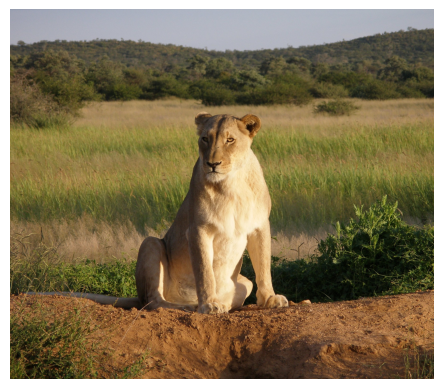

id: 1, distance: 0.7942215800285339, metadata: {}, document: None, uri: /home/vboxuser/Documents/nlp-clean/notebooks/images_vectordb/tiger.jpeg


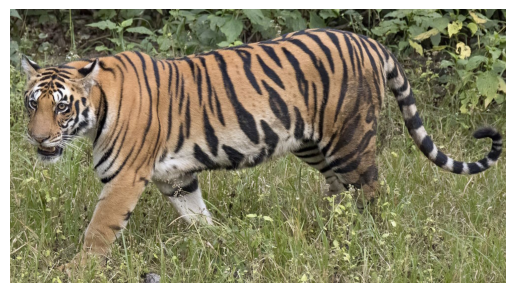

In [162]:
# search images

query_texts = ['lion']
query_results = collection.query(
  query_texts = query_texts,
  n_results = 4,
  include = ['documents','distances','metadatas','data','uris']
)

print_query_results(query_texts,query_results)